In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats

In [4]:
df = pd.read_csv("spread_locator_dataset.csv")
df

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success
...,...,...,...,...,...,...,...
215,10c2a8f2-89d0-485c-bf8f-9508d32a02fc,CUST5563,4356.76,2023-01-12,2,South,Fail
216,5618814b-f7e2-424d-9617-9fc8d8643370,CUST8579,2025.53,2023-01-29,6,South,Fail
217,5636c9e7-9d54-4654-9c89-fdf31be87d96,CUST5092,2648.08,2023-01-30,1,West,Fail
218,6ba09450-a455-4983-bbad-3dad292cc839,CUST2235,2338.62,2023-01-26,3,North,Success


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      220 non-null    str    
 1   customer_id         220 non-null    str    
 2   transaction_amount  220 non-null    float64
 3   transaction_date    220 non-null    str    
 4   transaction_count   220 non-null    int64  
 5   region              220 non-null    str    
 6   transaction_status  220 non-null    str    
dtypes: float64(1), int64(1), str(5)
memory usage: 12.2 KB


In [6]:
df.describe()

,transaction_amount,transaction_count
count,220.000000,220.000000
mean,3365.192409,2.854545
std,1985.705409,1.797189
min,804.420000,0.000000
25%,2124.205000,1.750000
50%,3077.715000,3.000000
75%,3950.737500,4.000000
max,20462.840000,9.000000


# Part A - Theory

## 1. Statistical Distribution

Statistical distribution describes how values are spread across a dataset. It helps understand patterns, probabilities, and variability.

Example:
Transaction amount distribution.

## 2. What is a Q-Q Plot and Why is it Used?

A **Q-Q (Quantile–Quantile) Plot** is a graphical technique used to compare the distribution of actual dataset values with a theoretical normal distribution. It helps determine whether the data follows a normal distribution.

### Purpose
- Check normality 
- Detect outliers

### Interpretation
- Straight line → Normal 
- Curve → Non-normal

## 3. Difference Between Discrete Distribution and Continuous Distribution

Statistical distributions are mainly divided into two types: **Discrete Distribution** and **Continuous Distribution**. These distributions describe how data values are represented and analyzed.

### Discrete Distribution
A discrete distribution is used when data consists of countable and separate values. The values cannot occur between two points.

Examples:
- Number of transactions per day
- Weekly transaction count
- Number of successful transactions


Common discrete distributions:
- Bernoulli Distribution
- Binomial Distribution
- Poisson Distribution

---

### Continuous Distribution
A continuous distribution is used when data can take any value within a given range. These values are usually measured.

Examples:
- Transaction amount

Common continuous distributions:
- Normal Distribution
- Log-Normal Distribution
- Power Law Distribution

| Feature | Discrete Distribution | Continuous Distribution |
|----------|----------------------|-------------------------|
| Definition | Represents countable values | Represents measurable values |
| Nature of Data | Separate and distinct values | Infinite values within a range |
| Data Type | Integer values | Decimal values |
| Probability | Probability of exact values | Probability over intervals |
| Function Used | Probability Mass Function (PMF) | Probability Density Function (PDF) |
| Graph Type | Bar Graph | Smooth Curve |
| Example | Number of transactions | Transaction amount (₹) |



## 4. Bernoulli Distribution

A **Bernoulli Distribution** is a discrete probability distribution that represents an experiment with only **two possible outcomes**: success or failure.

It is one of the simplest probability distributions and is commonly used when an event can either occur or not occur.

### Characteristics
- Only two outcomes are possible:
  - Success (1)
  - Failure (0)

### Example
Suppose a transaction can either be:

- Successful → 1
- Failed → 0

If the probability of a successful transaction is 0.8, then:

- P(Success) = 0.8
- P(Failure) = 0.2


## 5. Binomial Distribution

**Binomial Distribution** represents the probability of success in a Bernoulli Distribution over multiple trials.

Each trial has only two possible outcomes:
- Success
- Failure

### Example

A coin is tossed **5 times**.

Find the probability of getting exactly **3 heads**.

This is a **Binomial Distribution** because:
- Number of trials is fixed (5 tosses)
- Only two outcomes are possible (Head or Tail)
- Each toss has the same probability

## 6. Log Normal Distribution

A **Log Normal Distribution** is a probability distribution where the logarithm of the values follows a normal distribution.

It is commonly used for data that cannot have negative values and grows unevenly.

### Characteristics
- Values are always greater than 0
- Most values are small
- Few values are very large
- Distribution is right-skewed

### Example

Suppose the transaction amounts of customers are:

₹100, ₹200, ₹300, ₹500, ₹5000

Most customers spend small amounts, but a few customers spend very high amounts.

This type of data follows a **Log Normal Distribution**.

## 7. Power Law Distribution

A **Power Law Distribution** is a probability distribution where a small number of values are very large and most values are very small.

It is used to represent unequal distributions.

### Characteristics
- Most values are small
- Few values are extremely large
- Distribution is not balanced

### Example

In an online store:
- Most customers spend a small amount.
- A few customers spend a very high amount.

This follows a **Power Law Distribution**.





## 8. Box-Cox Transformation

A **Box-Cox Transformation** is a statistical technique used to transform non-normal data into a more normal distribution.

It helps improve data analysis and machine learning results.

### Characteristics
- Reduces skewness
- Makes data more normally distributed
- Improves model performance
- Stabilizes variance

### Formula

y(λ) = (x^λ − 1) / λ

### Example

Suppose transaction amounts are:

₹100, ₹200, ₹300, ₹5000

Since one value is much larger than others, Box-Cox Transformation can be applied to make the data more balanced.


## 9. Poisson Distribution

A **Poisson Distribution** is a probability distribution used to calculate the number of times an event occurs within a fixed period of time.

It is used when events happen randomly.

### Characteristics
- Counts number of events
- Events occur independently
- Fixed interval of time or space

### Example

Suppose a store receives **5 transactions per hour** on average.

Poisson Distribution can be used to find the probability of receiving a specific number of transactions in one hour.



## 10. Z-Score Probability

A **Z-Score Probability** is a statistical measure used to determine how far a value is from the mean of a dataset.

It is measured in terms of standard deviations.

### Characteristics
- Measures distance from the mean
- Helps identify unusual values
- Used to detect outliers

### Formula

Z = (X − μ) / σ

Where:
- X = Data value
- μ = Mean
- σ = Standard deviation

### Example

Suppose the average transaction amount is ₹500 and a customer spends ₹700.

The Z-score shows how far ₹700 is from the average transaction amount.

## 11. Difference Between PDF and CDF

PDF (Probability Density Function) and CDF (Cumulative Distribution Function) are used to describe probability distributions in statistics.

| Feature | PDF | CDF |
|----------|-----|-----|
| Full Form | Probability Density Function | Cumulative Distribution Function |
| Purpose | Shows probability at a specific value | Shows cumulative probability up to a value |
| Range | Probability density | Values between 0 and 1 |
| Graph | Curve | Increasing curve |
| Use | Individual probability | Total accumulated probability |

### PDF (Probability Density Function)

PDF shows the probability of a variable occurring at a particular value.

### Example

Finding the probability of a customer spending exactly ₹500.

---

### CDF (Cumulative Distribution Function)

CDF shows the probability that a variable is less than or equal to a given value.

### Example

Finding the probability of a customer spending up to ₹500.

---

# Part B

### 1. Bernoulli and Binomial Distribution 


In [9]:
# Bernoulli distribution (Transaction occurrence)
 
from scipy.stats import bernoulli

df['success']=df['transaction_status'].map({
'Success':1,
'Fail':0
})

p=df['success'].mean()

print("Probability of Success =",p)



Probability of Success = 0.44545454545454544


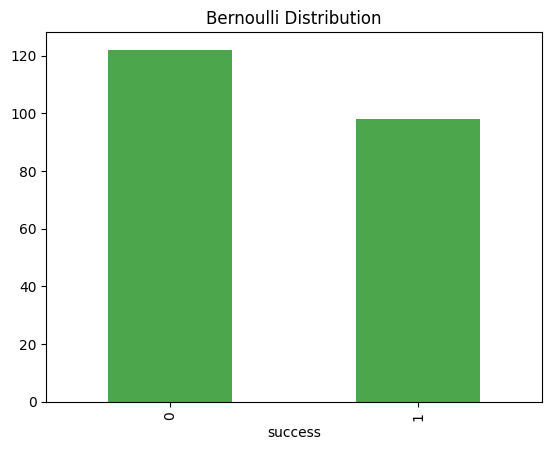

In [22]:
# visualization 

import matplotlib.pyplot as plt

df['success'].value_counts().plot( kind='bar', color="Green" , alpha=0.7)

plt.title("Bernoulli Distribution")
plt.show()

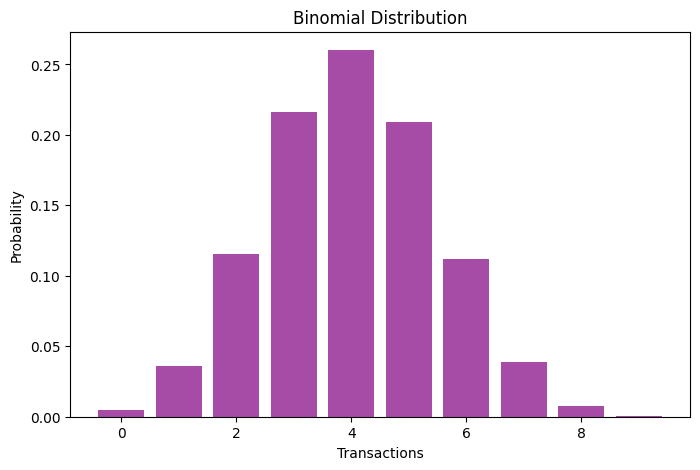

### 2. Poisson Distribution

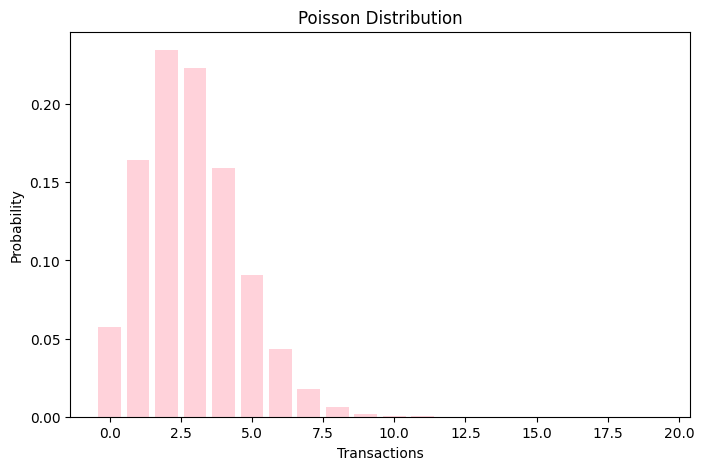

In [23]:
# Number of transactions per day

from scipy.stats import poisson

lam=df['transaction_count'].mean()

x=np.arange( 0, 20)

prob=poisson.pmf(x,lam)

plt.figure(figsize=(8,5))
plt.bar(x,prob , color="pink" , alpha = 0.7)
plt.title("Poisson Distribution")
plt.xlabel("Transactions")
plt.ylabel("Probability")
plt.show()

### 3. Log Normal Distribution And Power Law Distribution

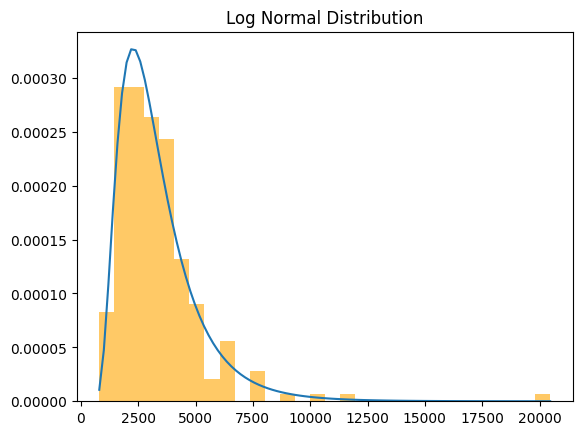

In [43]:
# Log Normal Distribution

from scipy.stats import lognorm

shape,loc,scale=lognorm.fit(df['transaction_amount'])

plt.hist(df['transaction_amount'],bins=30,density=True,alpha=0.6,color='orange')

x=np.linspace(
df['transaction_amount'].min(),
df['transaction_amount'].max(),
100)

pdf=lognorm.pdf(x,shape,loc,scale)
plt.plot(x,pdf)
plt.title("Log Normal Distribution")
plt.show()

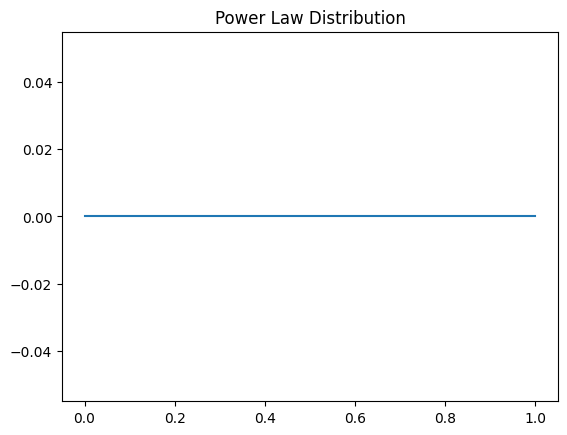

In [44]:
# Power Law Distribution

from scipy.stats import powerlaw

param=powerlaw.fit(df['transaction_amount'])
x=np.linspace(0,1,100)
plt.plot(x,powerlaw.pdf(x,*param))
plt.title("Power Law Distribution")
plt.show()

### 4. Q-Q Plot

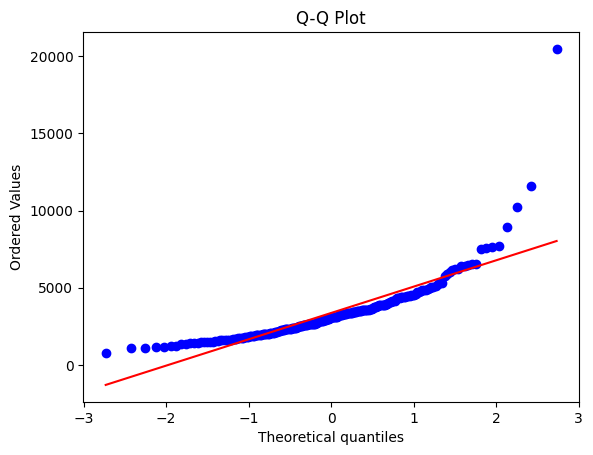

In [27]:
import scipy.stats as stats

stats.probplot(df['transaction_amount'],dist='norm',plot=plt)

plt.title("Q-Q Plot")
plt.show()

### **Conclusion**

Straight Line → Normal Distribution  
Curved Pattern → Non-Normal Distribution  
Far Points → Outliers

### 5. Box-Cox Transform

Lambda: -0.18083390743966327


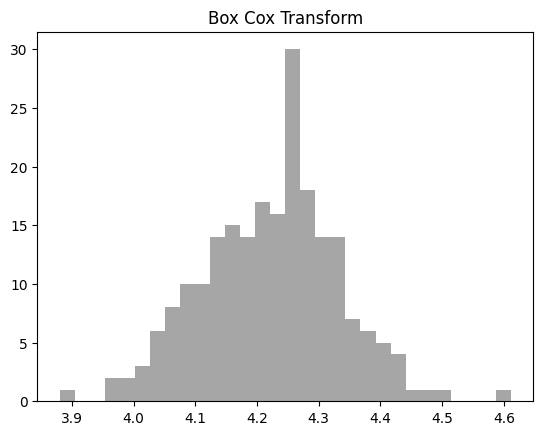

In [32]:
from scipy.stats import boxcox

transformed,lam=boxcox(df['transaction_amount'])
print("Lambda:",lam)

plt.hist(transformed,bins=30 , color = "gray" , alpha = 0.7)
plt.title("Box Cox Transform")
plt.show()

### 6. Z Score + Probability > ₹5000

In [34]:
from scipy.stats import zscore
from scipy.stats import norm

df['z_score']=zscore(
  df['transaction_amount'])

print(df[['transaction_amount','z_score']])

mean=df['transaction_amount'].mean()

std=df['transaction_amount'].std()

prob=1-norm.cdf(5000,mean,std)

print("Probability:",prob)

     transaction_amount   z_score
0               3821.34  0.230240
1               2781.84 -0.294446
2               4120.97  0.381477
3               6383.78  1.523626
4               2651.61 -0.360179
..                  ...       ...
215             4356.76  0.500492
216             2025.53 -0.676192
217             2648.08 -0.361961
218             2338.62 -0.518160
219             3105.52 -0.131069

[220 rows x 2 columns]
Probability: 0.20517209567554384


### **Conclusion**

Z-score helps identify unusual transaction amounts.

The probability exceeding ₹5000 indicates how often high-value transactions occur in the dataset.

### 7. PDF and CDF

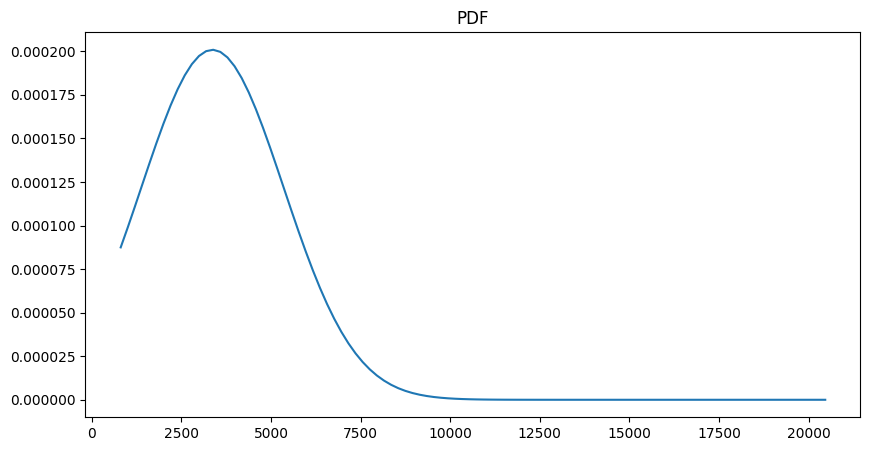

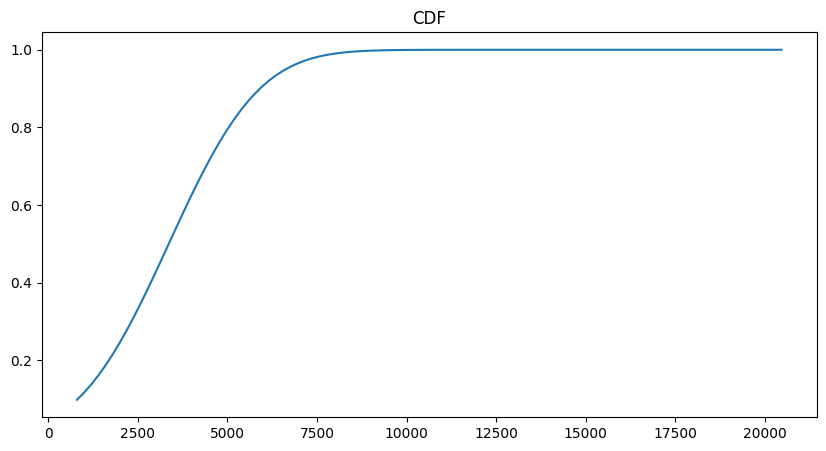

In [42]:
from scipy.stats import norm

x=np.linspace(
df['transaction_amount'].min() ,
df['transaction_amount'].max(),100)

pdf=norm.pdf(x,mean,std)

cdf=norm.cdf(x,mean,std)

plt.figure(figsize=(10,5))
plt.plot(x,pdf)
plt.title("PDF")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(x,cdf)
plt.title("CDF")
plt.show()

## **Conclusion**

PDF shows the probability distribution of transaction amounts.

CDF shows cumulative probability up to a given transaction amount.